In [1]:
%%writefile b_spider.py
import scrapy


class BooksToScrapeSpider(scrapy.Spider):
    name = "books_to_scrape"
    allowed_domains = ["books.toscrape.com"]

    start_urls = [
        "https://books.toscrape.com/catalogue/page-1.html"
    ]

    def parse(self, response):
        # Extract links of all books on the current page
        book_links = response.css("article.product_pod h3 a::attr(href)").getall()

        for link in book_links:
            yield response.follow(link, callback=self.parse_book)

        # Follow pagination only up to page 5
        next_page = response.css("li.next a::attr(href)").get()

        if next_page:
            current_page = int(response.url.split("page-")[1].split(".")[0])

            if current_page < 5:
                yield response.follow(next_page, callback=self.parse)

    def parse_book(self, response):
        # Extract product information
        yield {
            "title": response.css("div.product_main h1::text").get(),
            
            "category": response.css(
                "ul.breadcrumb li:nth-child(3) a::text"
            ).get(),
            
            "price": response.css(
                "div.product_main p.price_color::text"
            ).get(),
            
            "rating": response.css(
                "div.product_main p.star-rating::attr(class)"
            ).get().replace("star-rating ", ""),
            
            "availability": response.css(
                "div.product_main p.instock.availability::text"
            ).getall()[-1].strip(),
            
            "product_description": response.css(
                "#product_description ~ p::text"
            ).get(),
            
            "UPC": response.css(
                "table.table-striped tr:nth-child(1) td::text"
            ).get(),
            
            "number_of_reviews": response.css(
                "table.table-striped tr:nth-child(7) td::text"
            ).get(),
            
            "product_url": response.url
        }

Overwriting b_spider.py


### Task 1 - Data Scraping

In [4]:

import os
import sys
import subprocess



OUTPUT_CSV = "book_data.csv"


def run_spider(script_name: str, output_path: str):
    """Launches the Scrapy spider as a subprocess and reports the outcome."""
    if os.path.exists(output_path):
        os.remove(output_path)

    print(f"Using interpreter: {sys.executable}")
    print("Crawling books.toscrape.com — this usually takes 15-30 seconds...")

    cmd = f'"{sys.executable}" -m scrapy runspider {script_name} -O {output_path}'
    completed = subprocess.run(cmd, shell=True, capture_output=True, text=True)

    if os.path.exists(output_path):
        print(f"\nDone — saved to {os.path.abspath(output_path)}")
    else:
        print("\nScrapy did not produce an output file. Log below:")
        print(completed.stderr)

    return completed


result = run_spider("b_spider.py", OUTPUT_CSV)


Using interpreter: c:\Users\Administrator\miniconda3\envs\ml\python.exe
Crawling books.toscrape.com — this usually takes 15-30 seconds...

Done — saved to d:\ml\202618023_Drashti_DS605\book_data.csv


### Task 2-Data Preprocessing

In [5]:
import pandas as pd

df = pd.read_csv("book_data.csv")

# Total records
print("Total records:", len(df))

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Duplicate UPC values
print("\nDuplicate UPC values:", df["UPC"].duplicated().sum())

Total records: 100

Missing values:
title                  0
category               0
price                  0
rating                 0
availability           0
product_description    0
UPC                    0
number_of_reviews      0
product_url            0
dtype: int64

Duplicate UPC values: 0


In [6]:
# Remove extra spaces from text columns
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].str.strip()

# Remove duplicate books using UPC
df = df.drop_duplicates(subset="UPC")

# Handle missing descriptions
df["product_description"] = df["product_description"].fillna("No description available")

# Save cleaned data
df.to_csv("books_cleaned.csv", index=False)

print("Cleaned data saved successfully!")
print("Total records:", len(df))
print("Missing values:")
print(df.isnull().sum())

Cleaned data saved successfully!
Total records: 100
Missing values:
title                  0
category               0
price                  0
rating                 0
availability           0
product_description    0
UPC                    0
number_of_reviews      0
product_url            0
dtype: int64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_9476\1986937371.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


In [7]:
# Convert price to numeric
df["price"] = df["price"].str.replace("£", "", regex=False).astype(float)

# Convert rating words to numbers
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating"] = df["rating"].map(rating_map)

# Extract available stock count
df["stock_count"] = df["availability"].str.extract(r"(\d+)").astype(int)

# Save the processed data
df.to_csv("books_cleaned.csv", index=False)

print(df[["price", "rating", "availability", "stock_count"]].head())

   price  rating             availability  stock_count
0  13.99       2  In stock (19 available)           19
1  22.65       1  In stock (19 available)           19
2  20.66       4  In stock (19 available)           19
3  51.33       2  In stock (19 available)           19
4  37.59       1  In stock (19 available)           19


In [8]:
# 1. Count words in product description
df["description_word_count"] = df["product_description"].fillna("").str.split().str.len()

# 2. Create price bands
df["price_band"] = pd.cut(
    df["price"],
    bins=[0, 20, 40, 60, 100],
    labels=["Low", "Medium", "High", "Very High"]
)

# 3. Create affordability score
df["affordability_score"] = 100 - (df["price"] / df["price"].max() * 100)

# 4. Create recommended feature
df["recommended"] = (
    (df["rating"] >= 4) & 
    (df["price"] <= df["price"].median())
)

# Save the final data
df.to_csv("books_cleaned.csv", index=False)

print(df[[
    "title",
    "description_word_count",
    "price_band",
    "affordability_score",
    "recommended"
]].head())

                                               title  description_word_count  \
0     Starving Hearts (Triangular Trade Trilogy, #1)                     196   
1                                    The Requiem Red                     170   
2                              Shakespeare's Sonnets                     143   
3                       Libertarianism for Beginners                     195   
4  Mesaerion: The Best Science Fiction Stories 18...                     283   

  price_band  affordability_score  recommended  
0        Low            75.924970        False  
1     Medium            61.022199        False  
2     Medium            64.446739         True  
3       High            11.667527        False  
4     Medium            35.312339        False  


## Visualization and Analysis

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

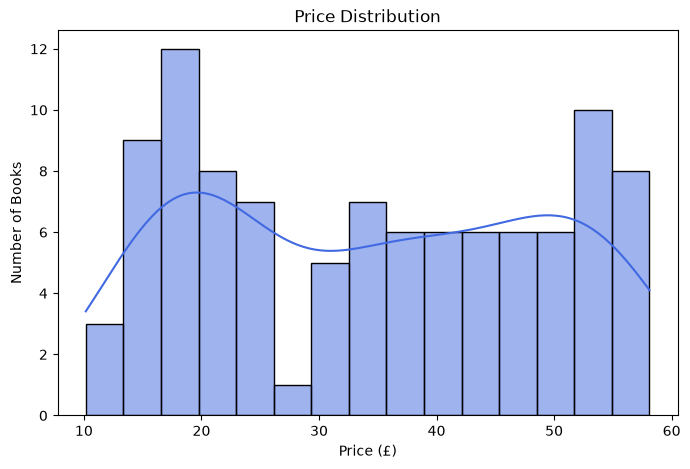

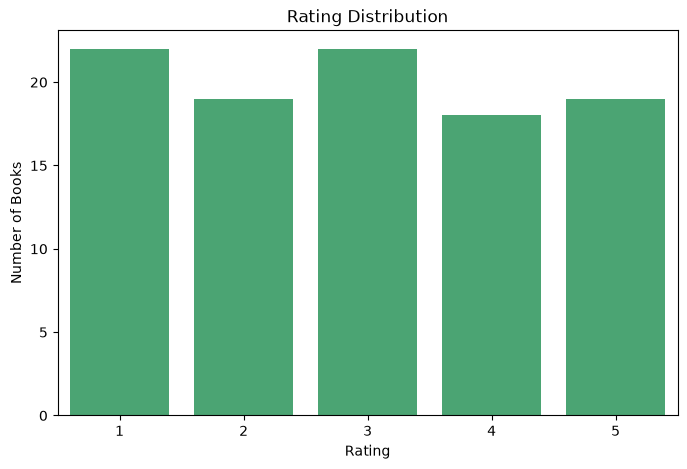

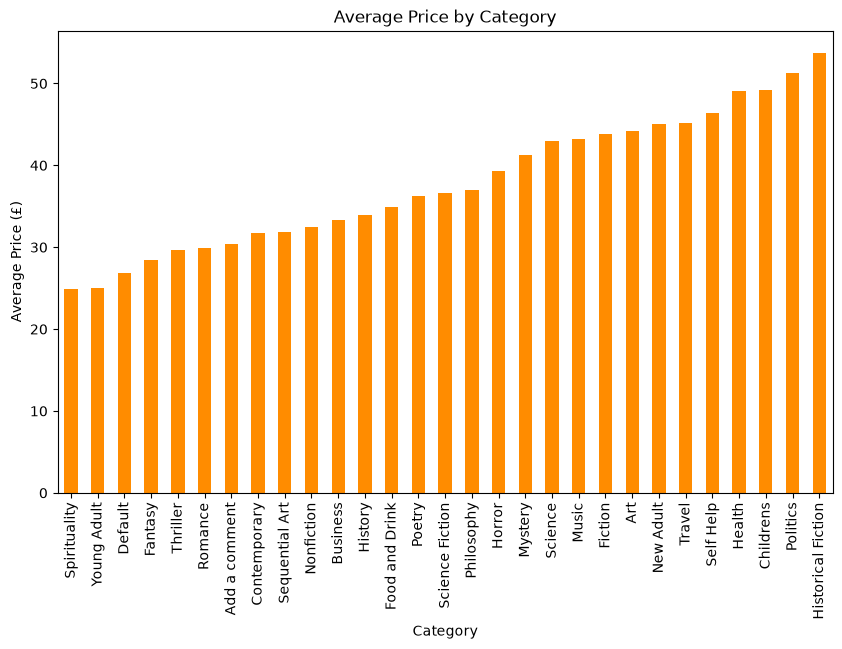

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9476\3565383659.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


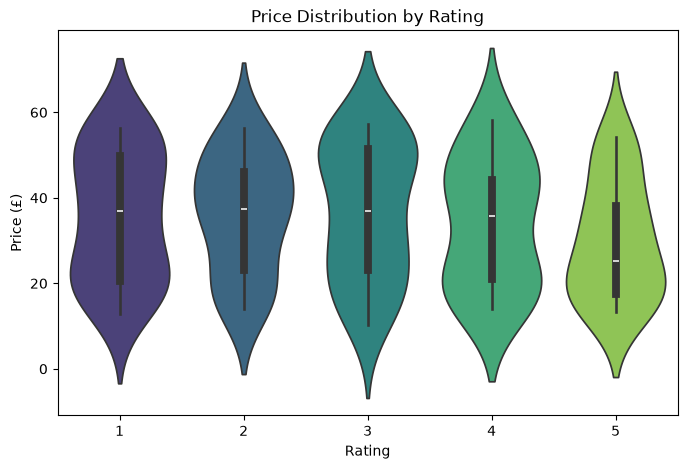

In [14]:
# 1. Price Distribution 
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=15, kde=True, color="royalblue")
plt.title("Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.show()


# Rating Distribution 
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="rating",
    color="mediumseagreen"
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.xticks([0, 1, 2, 3, 4], [1, 2, 3, 4, 5])
plt.show()


# 3. Average Price by Category
avg_price = df.groupby("category")["price"].mean().sort_values()

plt.figure(figsize=(10, 6))
avg_price.plot(kind="bar", color="darkorange")
plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=90)
plt.show()


# 4. Price vs Rating 
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="rating",
    y="price",
    palette="viridis"
)

plt.title("Price Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.show()

In [15]:
from wordcloud import WordCloud


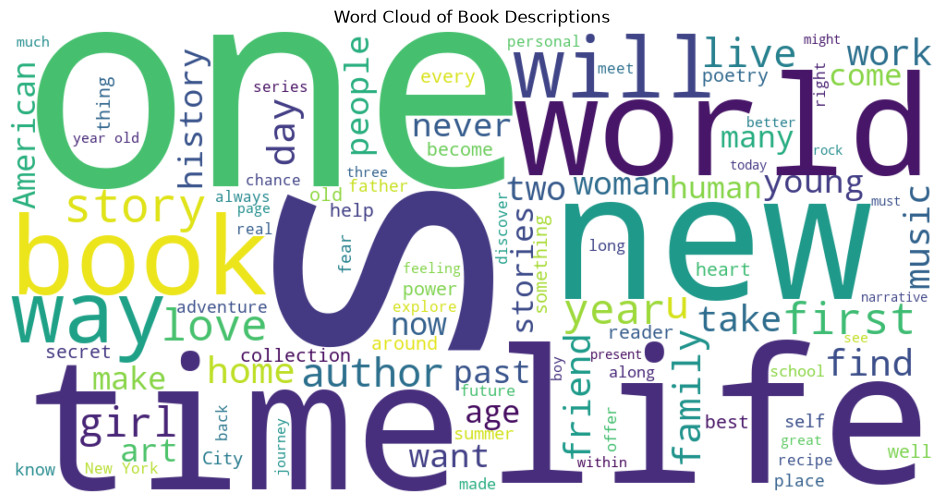

In [16]:
# Combine all book descriptions
text = " ".join(df["product_description"].fillna("").astype(str))

# Create word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis",
    max_words=100
).generate(text)

# Display word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Book Descriptions")
plt.show()

In [17]:
import seaborn as sns

Summary Statistics:
            price      rating  stock_count
count  100.000000  100.000000   100.000000
mean    34.560700    2.930000    17.180000
std     14.638531    1.423149     1.479694
min     10.160000    1.000000    16.000000
25%     19.897500    2.000000    16.000000
50%     34.775000    3.000000    16.000000
75%     47.967500    4.000000    19.000000
max     58.110000    5.000000    22.000000

Number of books by category:
category
Sequential Art    14
Nonfiction        12
Default            9
Poetry             7
Food and Drink     5
Fiction            5
Add a comment      5
Young Adult        4
History            4
Fantasy            4
Name: count, dtype: int64

Average price by category:
category
Historical Fiction    53.740000
Politics              51.330000
Childrens             49.220000
Health                49.050000
Self Help             46.350000
Travel                45.170000
New Adult             45.070000
Art                   44.180000
Fiction               43.

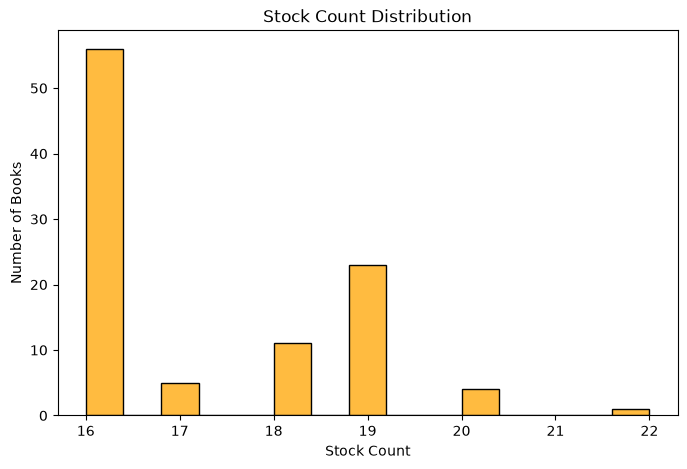


Missing Values:
title                     0
category                  0
price                     0
rating                    0
availability              0
product_description       0
UPC                       0
number_of_reviews         0
product_url               0
stock_count               0
description_word_count    0
price_band                0
affordability_score       0
recommended               0
dtype: int64

Most Expensive Books:
                                                title  price  rating
70       The Death of Humanity: and the Case for Life  58.11       4
50                     Slow States of Collapse: Poems  57.31       3
10  Our Band Could Be Your Life: Scenes from the A...  57.25       3
40                                The Past Never Ends  56.50       4
39  The Pioneer Woman Cooks: Dinnertime: Comfort C...  56.41       1

Cheapest Books:
                                                title  price  rating
91                                           Patience  

In [19]:
# 1. Summary statistics
print("Summary Statistics:")
print(df[["price", "rating", "stock_count"]].describe())


# 2. Category patterns
print("\nNumber of books by category:")
print(df["category"].value_counts().head(10))

print("\nAverage price by category:")
print(df.groupby("category")["price"].mean().sort_values(ascending=False).head(10))


# 3. Highly rated books
print("\nHighly Rated Books:")
print(df[df["rating"] == 5][["title", "price", "category"]].head(10))


# 4. Stock patterns
print("\nStock Statistics:")
print(df["stock_count"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df["stock_count"], bins=15, color="orange")
plt.title("Stock Count Distribution")
plt.xlabel("Stock Count")
plt.ylabel("Number of Books")
plt.show()

# 5. Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


# 6. Check unusual prices
print("\nMost Expensive Books:")
print(df.nlargest(5, "price")[["title", "price", "rating"]])

print("\nCheapest Books:")
print(df.nsmallest(5, "price")[["title", "price", "rating"]])

### Task 4 - Insights and Interpretation

In [20]:
# Price and rating: The price vs rating plot shows that there is no strong relationship between price and rating. Expensive books are not always highly rated.
# Highly rated books: Books with a 5-star rating are the highest-rated books and can be considered highly rated.
# Most represented categories: Some categories have many more books than others, showing that the dataset is not evenly distributed across categories.
# Expensive categories: The average-price-by-category plot shows that some categories have a higher average price, while others are more affordable.
# Best value books: Books with a high rating and relatively low price provide better value for money.

In [21]:
# The dataset contains only 100 books from the first 5 pages, so it may not represent the whole website.
# The website does not provide customer review text, so book descriptions were used for the word cloud.
# The relationship between price and rating cannot prove that one causes the other.